# Notebook 02 — Predição Autorregressiva (H=3 meses)

> **Objetivo:** Treinar e avaliar ARIMA, XGBoost e SVR para prever a inadimplência total com horizonte de **3 meses à frente**, usando apenas o histórico da própria série
>
> Este notebook serve como **baseline autorregressivo**: o ganho dos modelos de sentimento será avaliado no Notebook 06 pela comparação com estes resultados.
>
> **Critério de seleção de lags/ordem:** menor RMSE em validação walk-forward no conjunto de **treinamento**. Correlação é usada apenas como exploração, não como critério de escolha.


In [10]:
%pip install pandas numpy matplotlib statsmodels scikit-learn xgboost-cpu


[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## Funções Auxiliares

| Métrica | Interpretação |
|---|---|
| **MAE** | Erro médio absoluto em pontos percentuais |
| **RMSE** | Penaliza mais erros grandes; mesma unidade da série |
| **R²** | Quanto da variância foi explicada (1 = perfeito) |
| **Bias** | Erro sistemático: positivo = modelo subestima |

**Estratégia:** previsão direta H=3 meses com validação temporal.

- **Features candidatas:** `inad_total` | `inad_total_L1` | … | `inad_total_L6`.
- **Target:** `inad_total_tplus3` = inadimplência em t+3 (`shift(−3)`, criado uma única vez na célula de carregamento).
- **Split treino/teste:** baseado em `data_alvo`, isto é, o mês que está sendo previsto.
- **Seleção dos lags:** feita pelo menor RMSE no conjunto de treinamento.
- **Avaliação XGBoost/SVR:** usa walk-forward. Para prever a linha de referência `t`, o modelo só treina com observações cujo `data_alvo` já teria sido observado até `t`. Isso evita vazamento de informação em H=3.
- **ARIMA:** seleciona a ordem autorregressiva `p` pelo menor RMSE no treinamento e avalia o teste com horizonte H=3.


In [11]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from xgboost import XGBRegressor

#  Métricas
def metricas_regr(y_true, y_pred) -> dict:
    """Calcula métricas de regressão para comparação dos modelos."""
    y_true = pd.Series(y_true).astype(float)
    y_pred = pd.Series(y_pred, index=y_true.index).astype(float)

    mae  = mean_absolute_error(y_true, y_pred)
    rmse = root_mean_squared_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    bias = float(np.mean(y_true - y_pred))

    lr = LinearRegression().fit(
        np.array(y_true).reshape(-1, 1),
        np.array(y_pred)
    )

    return {
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "Bias (obs - prev)": bias,
        "Slope pred~obs": float(lr.coef_[0]),
        "Intercept": float(lr.intercept_),
    }


In [12]:
# 1. Carregar base
CAMINHO_BASE = "base_series.csv"

dados_base = pd.read_csv("base_series.csv")
dados_base["data"] = pd.to_datetime(dados_base["data"])
dados_base = dados_base[dados_base["data"] < "2026-01-01"].copy()
dados_base = dados_base.sort_values("data").reset_index(drop=True)

print(f"Período: {dados_base['data'].min().date()} até {dados_base['data'].max().date()}")
print(f"Observações brutas: {len(dados_base)}")
dados_base


Período: 2019-01-01 até 2025-12-01
Observações brutas: 84


,data,inad_total,inad_total_L1,inad_total_L2,inad_total_L3,inad_total_L4,inad_total_L5,inad_total_L6
0,2019-01-01,2.95,NaN,NaN,NaN,NaN,NaN,NaN
1,2019-02-01,2.91,2.95,NaN,NaN,NaN,NaN,NaN
2,2019-03-01,2.99,2.91,2.95,NaN,NaN,NaN,NaN
3,2019-04-01,3.02,2.99,2.91,2.95,NaN,NaN,NaN
4,2019-05-01,3.05,3.02,2.99,2.91,2.95,NaN,NaN
...,...,...,...,...,...,...,...,...
79,2025-08-01,3.95,3.77,3.57,3.54,3.50,3.28,3.26
80,2025-09-01,3.91,3.95,3.77,3.57,3.54,3.50,3.28
81,2025-10-01,4.00,3.91,3.95,3.77,3.57,3.54,3.50
82,2025-11-01,4.05,4.00,3.91,3.95,3.77,3.57,3.54


In [13]:
# =============================================================
# 3. Criar target e data_alvo = inad_total_tplus3 = inadimplência em t+3
#    data_alvo = mês que está sendo previsto (t + 3 meses)
#
#    A separação treino/teste usa data_alvo (mês previsto),
#    não a data de referência t, evitando ambiguidade:
#    ex.: ref=out/2022 → alvo=jan/2023 (pertence ao período de teste)
# =============================================================
H = 3

df_model = dados_base.copy()
df_model["data_alvo"] = df_model["data"] + pd.DateOffset(months=H)
df_model["inad_total_tplus3"] = df_model["inad_total"].shift(-H)

# Tabela de conferência (ainda com NaN)
cols_conf = ["data", "data_alvo", "inad_total_tplus3", "inad_total", "inad_total_L1",	"inad_total_L2",	"inad_total_L3",	"inad_total_L4",	"inad_total_L5",	"inad_total_L6"]
print()
print("=== TABELA DE CONFERÊNCIA — data_alvo | target | lags ===")
print(df_model[cols_conf].head(10).round(4).to_string(index=False))
print("...")
print(df_model[cols_conf].tail(5).round(4).to_string(index=False))

df_model


=== TABELA DE CONFERÊNCIA — data_alvo | target | lags ===
      data  data_alvo  inad_total_tplus3  inad_total  inad_total_L1  inad_total_L2  inad_total_L3  inad_total_L4  inad_total_L5  inad_total_L6
2019-01-01 2019-04-01               3.02        2.95            NaN            NaN            NaN            NaN            NaN            NaN
2019-02-01 2019-05-01               3.05        2.91           2.95            NaN            NaN            NaN            NaN            NaN
2019-03-01 2019-06-01               2.95        2.99           2.91           2.95            NaN            NaN            NaN            NaN
2019-04-01 2019-07-01               3.06        3.02           2.99           2.91           2.95            NaN            NaN            NaN
2019-05-01 2019-08-01               3.04        3.05           3.02           2.99           2.91           2.95            NaN            NaN
2019-06-01 2019-09-01               3.06        2.95           3.05           3.02 

/tmp/ipykernel_25770/3674078021.py:19: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  print(df_model[cols_conf].head(10).round(4).to_string(index=False))
/tmp/ipykernel_25770/3674078021.py:21: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  print(df_model[cols_conf].tail(5).round(4).to_string(index=False))


,data,inad_total,inad_total_L1,inad_total_L2,inad_total_L3,inad_total_L4,inad_total_L5,inad_total_L6,data_alvo,inad_total_tplus3
0,2019-01-01,2.95,NaN,NaN,NaN,NaN,NaN,NaN,2019-04-01,3.02
1,2019-02-01,2.91,2.95,NaN,NaN,NaN,NaN,NaN,2019-05-01,3.05
2,2019-03-01,2.99,2.91,2.95,NaN,NaN,NaN,NaN,2019-06-01,2.95
3,2019-04-01,3.02,2.99,2.91,2.95,NaN,NaN,NaN,2019-07-01,3.06
4,2019-05-01,3.05,3.02,2.99,2.91,2.95,NaN,NaN,2019-08-01,3.04
...,...,...,...,...,...,...,...,...,...,...
79,2025-08-01,3.95,3.77,3.57,3.54,3.50,3.28,3.26,2025-11-01,4.05
80,2025-09-01,3.91,3.95,3.77,3.57,3.54,3.50,3.28,2025-12-01,4.02
81,2025-10-01,4.00,3.91,3.95,3.77,3.57,3.54,3.50,2026-01-01,NaN
82,2025-11-01,4.05,4.00,3.91,3.95,3.77,3.57,3.54,2026-02-01,NaN


In [14]:
# =============================================================
# 4. Base de modelagem — dropna() 
# =============================================================
df_fit = df_model[cols_conf].dropna().copy()

df_fit


,data,data_alvo,inad_total_tplus3,inad_total,inad_total_L1,inad_total_L2,inad_total_L3,inad_total_L4,inad_total_L5,inad_total_L6
6,2019-07-01,2019-10-01,3.03,3.06,2.95,3.05,3.02,2.99,2.91,2.95
7,2019-08-01,2019-11-01,3.00,3.04,3.06,2.95,3.05,3.02,2.99,2.91
8,2019-09-01,2019-12-01,2.94,3.06,3.04,3.06,2.95,3.05,3.02,2.99
9,2019-10-01,2020-01-01,3.00,3.03,3.06,3.04,3.06,2.95,3.05,3.02
10,2019-11-01,2020-02-01,3.04,3.00,3.03,3.06,3.04,3.06,2.95,3.05
...,...,...,...,...,...,...,...,...,...,...
76,2025-05-01,2025-08-01,3.95,3.54,3.50,3.28,3.26,3.19,2.95,3.14
77,2025-06-01,2025-09-01,3.91,3.57,3.54,3.50,3.28,3.26,3.19,2.95
78,2025-07-01,2025-10-01,4.00,3.77,3.57,3.54,3.50,3.28,3.26,3.19
79,2025-08-01,2025-11-01,4.05,3.95,3.77,3.57,3.54,3.50,3.28,3.26


In [15]:
# =============================================================
# 5. Split treino/teste — pela data_alvo (mês que está prevendo)
# =============================================================
SPLIT_DATE   = "01/01/2024"
split_dt   = pd.to_datetime(SPLIT_DATE, dayfirst=True)
mask_treino = df_fit["data_alvo"] < split_dt
mask_teste  = df_fit["data_alvo"] >= split_dt

print()
print("=== VALIDAÇÃO DO SPLIT (por data_alvo) ===")
print(f"Treino: alvo de {df_fit.loc[mask_treino, 'data_alvo'].min().date()} "
      f"até {df_fit.loc[mask_treino, 'data_alvo'].max().date()} "
      f"| {mask_treino.sum()} obs  "
      f"(ref: {df_fit.loc[mask_treino, 'data'].min().date()} "
      f"→ {df_fit.loc[mask_treino, 'data'].max().date()})")
print(f"Teste:  alvo de {df_fit.loc[mask_teste, 'data_alvo'].min().date()} "
      f"até {df_fit.loc[mask_teste, 'data_alvo'].max().date()} "
      f"| {mask_teste.sum()} obs  "
      f"(ref: {df_fit.loc[mask_teste, 'data'].min().date()} "
      f"→ {df_fit.loc[mask_teste, 'data'].max().date()})")

lags = [ "inad_total_L1", "inad_total_L2", "inad_total_L3",	"inad_total_L4",	"inad_total_L5",	"inad_total_L6"]

features_check = lags
has_future = any("tplus" in c for c in features_check)
print(f"\nFeatures contêm 'tplus': {has_future}  ← deve ser False (sem leakage)")

train_size_global = int(mask_treino.sum())


=== VALIDAÇÃO DO SPLIT (por data_alvo) ===
Treino: alvo de 2019-10-01 até 2023-12-01 | 51 obs  (ref: 2019-07-01 → 2023-09-01)
Teste:  alvo de 2024-01-01 até 2025-12-01 | 24 obs  (ref: 2023-10-01 → 2025-09-01)

Features contêm 'tplus': False  ← deve ser False (sem leakage)


## Estrutura da Tabela de Lags e Critério de Seleção

| Coluna | Significado |
|---|---|
| `inad_total` | Inadimplência observada no mês de referência **t** |
| `inad_total_L1` | `shift(1)` — um mês antes |
| `inad_total_L2` | `shift(2)` — dois meses antes |
| `inad_total_L3` | `shift(3)` — três meses antes |
| `inad_total_L4` | `shift(4)` — quatro meses antes |
| `inad_total_L5` | `shift(5)` — cinco meses antes |
| `inad_total_L6` | `shift(6)` — seis meses antes |
| `data_alvo` | Mês que está sendo previsto (`mes + 3 meses`) |
| `inad_total_tplus3` | Inadimplência em t+3 — **variável-alvo** |

**Nota sobre o split treino/teste:** o corte é feito por `data_alvo`, não pela data de referência. Isso evita que observações cujo alvo cai no período de teste sejam tratadas como treino. Por exemplo: referência=out/2022 → alvo=jan/2023 pertence ao **teste**.

**Critério de seleção de lags:**

A seleção do número de lags é realizada com base no erro médio de previsão obtido em validação temporal no conjunto de treinamento. Para isso, são testadas diferentes quantidades de valores históricos da inadimplência, e a configuração com menor **RMSE** é selecionada para avaliação final no conjunto de teste.

Para XGBoost e SVR, a validação usa **gap temporal**: quando o modelo prevê uma linha com mês de referência `t`, ele só treina com observações cujo `data_alvo` já teria sido conhecido até `t`. Dessa forma, a seleção dos lags não utiliza informação futura e não é baseada apenas na correlação.

O conjunto de teste é mantido separado da etapa de seleção dos lags, sendo utilizado apenas para a avaliação final dos modelos.


## ARIMA — Horizonte H=3

Diferentemente dos modelos tabulares, como XGBoost e SVR, o modelo ARIMA não utiliza colunas de lags criadas manualmente como variáveis explicativas. No ARIMA, a dependência temporal é incorporada diretamente pela estrutura do próprio modelo. O parâmetro p representa a quantidade de valores passados da série considerados na parte autorregressiva; o parâmetro d indica o número de diferenciações aplicadas para tornar a série estacionária; e o parâmetro q representa a estrutura de médias móveis associada aos erros passados. Por esse motivo, a modelagem ARIMA foi realizada diretamente sobre a série temporal de inadimplência, sem o uso das colunas inad_total_L1, inad_total_L2, ..., inad_total_L6.

$$I_{t+3} \leftarrow I_{t},\, I_{t-1},\, \ldots,\, I_{t-p+1}$$

**Seleção:** testa ARIMA(p,0,0) com p ∈ {1,2,3,4,5,6} e escolhe pelo **menor RMSE em walk-forward no conjunto de treinamento**. O AIC é reportado como informação complementar.

A correção de bias é estimada exclusivamente no conjunto de treino e aplicada às previsões do teste. Por isso, a versão com bias é reportada como benchmark principal, desde que a estimação do bias não utilize informações do período de teste.


In [16]:
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

In [17]:
# =============================================================
# ARIMA — modelo sem variáveis externas
# =============================================================

def teste_adf_serie(y: pd.Series):
    """
    Aplica o teste ADF — Dickey-Fuller aumentado, usado para avaliar
    se a série é estacionária, isto é, se não apresenta tendência estocástica forte.
    """
    y = y.dropna().astype(float)

    resultado = adfuller(y)

    print("=== Teste ADF — estacionariedade ===")
    print(f"Estatística ADF: {resultado[0]:.4f}")
    print(f"p-valor:         {resultado[1]:.4f}")

    if resultado[1] <= 0.05:
        print("Interpretação: há indício de estacionariedade. Sugestão inicial: d = 0.")
        d_sugerido = 0
    else:
        print("Interpretação: há indício de não estacionariedade. Sugestão inicial: d = 1.")
        d_sugerido = 1

    return d_sugerido


def plotar_acf_pacf(y: pd.Series, d: int = 0):
    """
    Plota ACF e PACF.

    ACF — função de autocorrelação: mostra a correlação da série com seus valores passados.
    PACF — autocorrelação parcial: ajuda a observar quais defasagens têm efeito mais direto.
    """
    y = y.dropna().astype(float)

    if d > 0:
        serie_analise = y.diff(d).dropna()
        titulo = f"Série após {d} diferença(s)"
    else:
        serie_analise = y
        titulo = "Série original"

    max_lags = min(24, max(1, len(serie_analise) // 2 - 1))

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    axes[0].plot(serie_analise)
    axes[0].set_title(titulo)

    plot_acf(serie_analise, lags=max_lags, ax=axes[1])
    axes[1].set_title("ACF")

    plot_pacf(serie_analise, lags=max_lags, ax=axes[2], method="ywm")
    axes[2].set_title("PACF")

    plt.tight_layout()
    plt.show()


def ajustar_arima(endog: pd.Series, order=(1, 0, 0)):
    """
    Ajusta um modelo ARIMA(p,d,q) diretamente pela classe ARIMA do statsmodels.

    p = número de termos autorregressivos, isto é, valores passados da própria série.
    d = número de diferenciações para tornar a série estacionária.
    q = número de termos de médias móveis, isto é, erros passados usados no modelo.
    """
    endog = endog.dropna().astype(float)

    modelo = ARIMA(
        endog,
        order=order,
        enforce_stationarity=True,
        enforce_invertibility=True
    )

    return modelo.fit(method_kwargs={"maxiter": 700})


def selecionar_ordem_arima_aic(
    y_treino: pd.Series,
    p_values=range(0, 7),
    d_values=(0, 1),
    q_values=range(0, 7)
):
    """
    Testa combinações ARIMA(p,d,q) e seleciona o modelo com menor AIC.

    AIC — Critério de Informação de Akaike, métrica que compara modelos
    considerando ajuste e complexidade. Quanto menor o AIC, melhor o equilíbrio
    entre aderência aos dados e parcimônia.
    """
    y_treino = y_treino.dropna().astype(float)

    resultados = []

    for p, d, q in itertools.product(p_values, d_values, q_values):

        # Evita modelo sem parte AR e sem parte MA.
        # ARIMA(0,d,0) pode ser testado, mas aqui deixamos fora para focar em modelos com dinâmica temporal.
        if p == 0 and q == 0:
            continue

        try:
            ajuste = ajustar_arima(y_treino, order=(p, d, q))

            resultados.append({
                "modelo": f"ARIMA({p},{d},{q})",
                "p": p,
                "d": d,
                "q": q,
                "ordem_arima": (p, d, q),
                "AIC": ajuste.aic,
                "BIC": ajuste.bic,
                "convergiu": True
            })

        except Exception as e:
            resultados.append({
                "modelo": f"ARIMA({p},{d},{q})",
                "p": p,
                "d": d,
                "q": q,
                "ordem_arima": (p, d, q),
                "AIC": np.nan,
                "BIC": np.nan,
                "convergiu": False
            })

    df_resultados = (
        pd.DataFrame(resultados)
        .dropna(subset=["AIC"])
        .sort_values("AIC")
        .reset_index(drop=True)
    )

    if df_resultados.empty:
        raise ValueError("Nenhum modelo ARIMA válido foi estimado.")

    melhor_ordem = tuple(df_resultados.loc[0, "ordem_arima"])

    return melhor_ordem, df_resultados


def diagnostico_residuos_arima(ajuste):
    """
    Gera gráficos de diagnóstico dos resíduos.

    Resíduos são os erros do modelo. Em um bom ajuste, eles devem se comportar
    de forma aproximadamente aleatória, sem autocorrelação relevante.
    """
    residuos = pd.Series(ajuste.resid).dropna()

    max_lags = min(24, max(1, len(residuos) // 2 - 1))

    fig, axes = plt.subplots(2, 2, figsize=(14, 8))

    axes[0, 0].plot(residuos)
    axes[0, 0].axhline(0, linestyle="--")
    axes[0, 0].set_title("Resíduos do ARIMA")

    plot_acf(residuos, lags=max_lags, ax=axes[0, 1])
    axes[0, 1].set_title("ACF dos resíduos")

    axes[1, 0].hist(residuos, bins=12, density=True)
    axes[1, 0].set_title("Histograma dos resíduos")

    sm.qqplot(residuos, line="45", ax=axes[1, 1])
    axes[1, 1].set_title("QQ-plot dos resíduos")

    plt.tight_layout()
    plt.show()


def walk_forward_arima_h(endog: pd.Series, train_size: int, order=(1, 0, 0), h: int = 3):
    """
    Executa walk-forward para ARIMA com horizonte h.

    Para cada posição i:
    - o modelo treina com endog.iloc[:i];
    - prevê h passos à frente;
    - guarda apenas a previsão do h-ésimo passo.
    """
    endog = endog.dropna().astype(float)

    previsoes = []
    limites_inf = []
    limites_sup = []
    idxs = []

    for i in range(train_size, len(endog) - h + 1):

        historico = endog.iloc[:i]

        try:
            ajuste = ajustar_arima(historico, order=order)

            forecast = ajuste.get_forecast(steps=h)

            yhat = float(forecast.predicted_mean.iloc[-1])

            conf_int = forecast.conf_int(alpha=0.05).iloc[-1]
            low = float(conf_int.iloc[0])
            upper = float(conf_int.iloc[1])

        except Exception:
            yhat = np.nan
            low = np.nan
            upper = np.nan

        previsoes.append(yhat)
        limites_inf.append(low)
        limites_sup.append(upper)
        idxs.append(endog.index[i + h - 1])

    return pd.DataFrame({
        "forecast": previsoes,
        "lower_95": limites_inf,
        "upper_95": limites_sup
    }, index=idxs).dropna()

=== Série utilizada no ARIMA ===
Série alinhada pela data_alvo, para manter comparação com XGBoost e SVR.
Início da série: 2019-10-01
Fim da série:    2025-12-01
Total de observações: 75
=== Teste ADF — estacionariedade ===
Estatística ADF: -0.7209
p-valor:         0.8412
Interpretação: há indício de não estacionariedade. Sugestão inicial: d = 1.


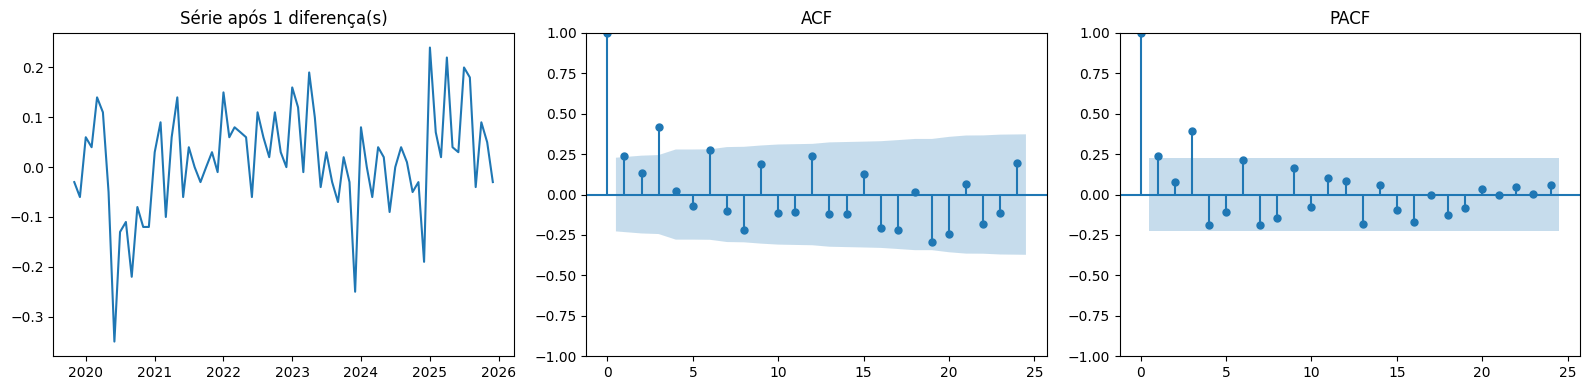


=== Split ARIMA — horizonte H=3 ===
Treino inicial: 2019-10-01 → 2023-10-01 (49 obs)
Primeiro alvo de teste: 2024-01-01 | Split: 2024-01-01
Último alvo de teste:   2025-12-01

Selecionando ordem ARIMA pelo menor AIC no conjunto de treino...


/usr/local/python/3.12.1/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/python/3.12.1/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/python/3.12.1/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/python/3.12.1/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/python/3.12.1/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information 


Tabela de seleção ARIMA por AIC:


,modelo,p,d,q,AIC,BIC,convergiu
0,"ARIMA(2,1,4)",2,1,4,-99.8054,-86.7070,True
1,"ARIMA(3,1,3)",3,1,3,-99.2501,-86.1517,True
2,"ARIMA(2,1,5)",2,1,5,-97.9870,-83.0174,True
3,"ARIMA(3,1,6)",3,1,6,-97.4010,-78.6890,True
4,"ARIMA(6,1,2)",6,1,2,-97.2263,-80.3855,True
5,"ARIMA(4,1,3)",4,1,3,-96.9878,-82.0182,True
6,"ARIMA(3,1,5)",3,1,5,-96.8890,-80.0482,True
7,"ARIMA(5,1,3)",5,1,3,-96.5892,-79.7484,True
8,"ARIMA(4,1,4)",4,1,4,-96.0648,-79.2240,True
9,"ARIMA(4,1,5)",4,1,5,-95.7898,-77.0778,True



Ordem selecionada pelo menor AIC: ARIMA(2, 1, 4)

Resumo do modelo ARIMA(2, 1, 4) ajustado no treino:


/usr/local/python/3.12.1/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/python/3.12.1/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/python/3.12.1/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:      inad_total_tplus3   No. Observations:                   49
Model:                 ARIMA(2, 1, 4)   Log Likelihood                  56.903
Date:                Mon, 04 May 2026   AIC                            -99.805
Time:                        01:25:53   BIC                            -86.707
Sample:                    10-01-2019   HQIC                           -94.855
                         - 10-01-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -1.0156      0.054    -18.879      0.000      -1.121      -0.910
ar.L2         -0.9886      0.032    -31.304      0.000      -1.050      -0.927
ma.L1          1.7069      4.939      0.346      0.7

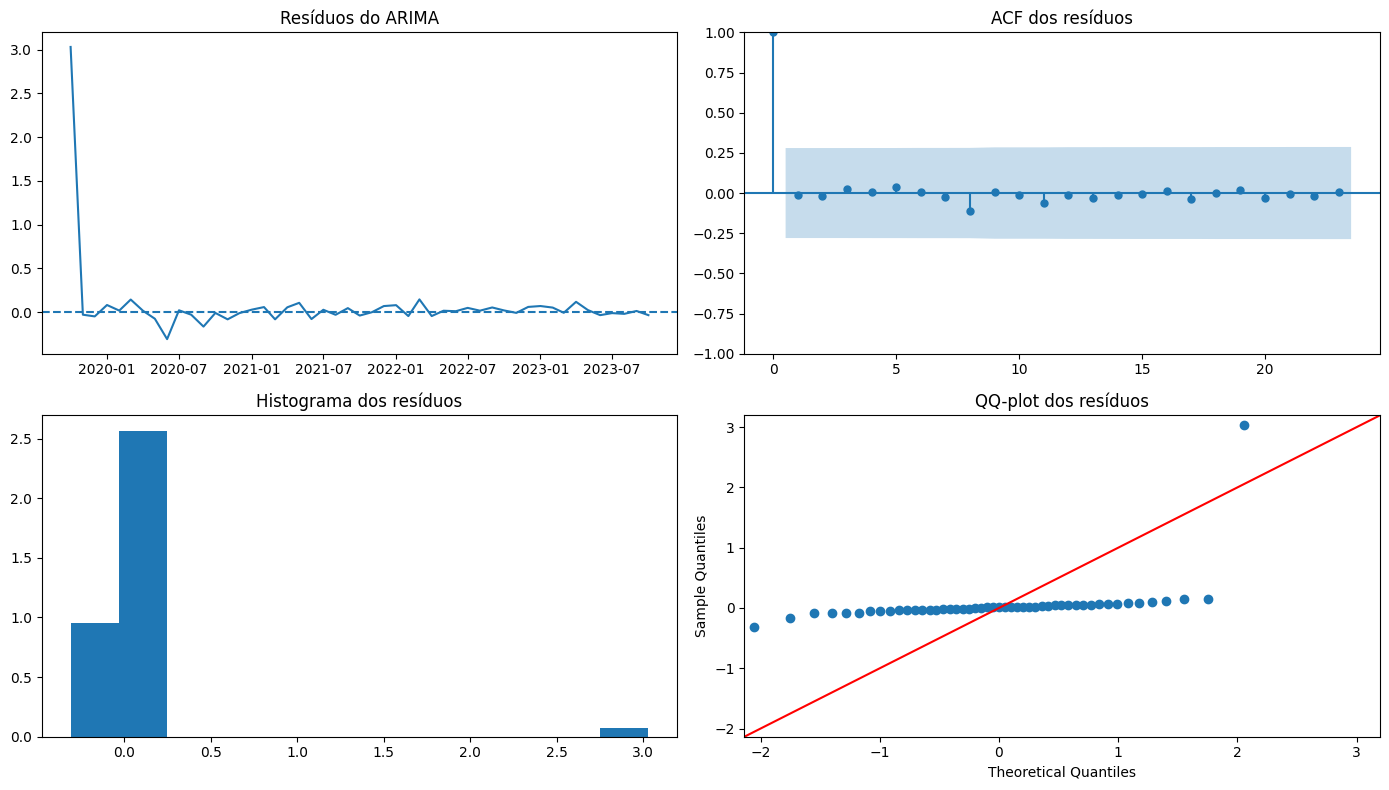

/usr/local/python/3.12.1/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/python/3.12.1/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/python/3.12.1/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/python/3.12.1/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/python/3.12.1/lib/python3.12/site-packages/statsmodels/base/model.py:607: Co


=== Bias correction ===
Bias estimado no treino: 0.076079
Interpretação: esse valor será somado às previsões do teste.


/usr/local/python/3.12.1/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/python/3.12.1/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/python/3.12.1/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/python/3.12.1/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/python/3.12.1/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information 


Métricas no teste — ARIMA(2, 1, 4):


,MAE,RMSE,R2,Bias (obs - prev),Slope pred~obs,Intercept
Modelo,,,,,,
"ARIMA(2, 1, 4) (h=3)",0.153840,0.197654,0.640054,0.072161,0.734977,0.836538
"ARIMA(2, 1, 4) (h=3) + bias",0.143668,0.184052,0.687889,-0.003919,0.734977,0.912617


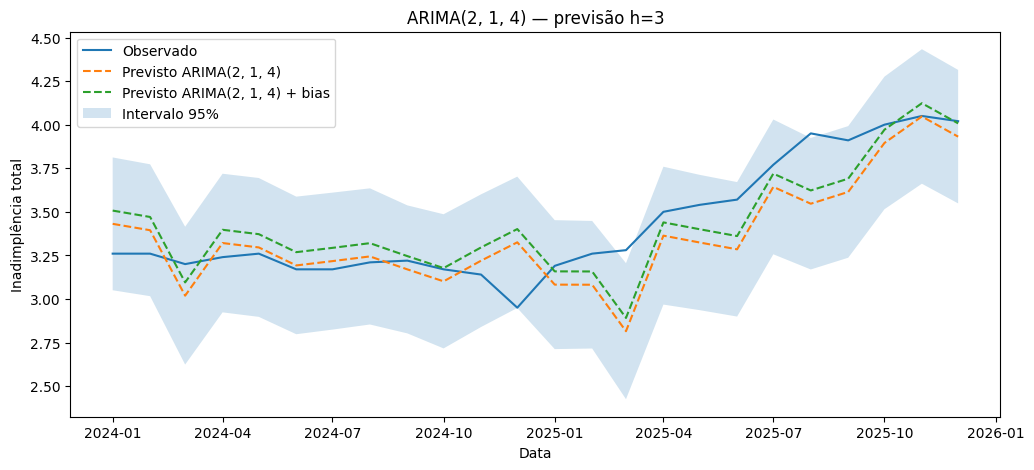

In [18]:
# =============================================================
# ARIMA — horizonte H=3
# Série usada: inad_total_tplus3 alinhada pela data_alvo
# Seleção da ordem ARIMA(p,d,q) por AIC
# Avaliação final por walk-forward no teste
# =============================================================

H = 3

# =============================================================
# 0. Série ARIMA alinhada à mesma base de comparação dos modelos tabulares
# =============================================================
# Para o ARIMA, não usamos as colunas de lag manualmente.
# Porém, para manter a comparabilidade com XGBoost e SVR,
# usamos a mesma janela temporal do df_fit.
#
# data_alvo = mês efetivamente previsto
# inad_total_tplus3 = valor observado da inadimplência nesse mês previsto

y_arima = (
    df_fit[["data_alvo", "inad_total_tplus3"]]
    .copy()
    .assign(data_alvo=lambda x: pd.to_datetime(x["data_alvo"]))
    .dropna(subset=["data_alvo", "inad_total_tplus3"])
    .drop_duplicates(subset="data_alvo", keep="last")
    .set_index("data_alvo")["inad_total_tplus3"]
    .sort_index()
    .astype(float)
)

y_arima.index.name = "data"

print("=== Série utilizada no ARIMA ===")
print("Série alinhada pela data_alvo, para manter comparação com XGBoost e SVR.")
print(f"Início da série: {y_arima.index.min().date()}")
print(f"Fim da série:    {y_arima.index.max().date()}")
print(f"Total de observações: {len(y_arima)}")

# =============================================================
# 1. Análise inicial: estacionariedade, ACF e PACF
# =============================================================
# ADF = teste de estacionariedade, isto é, verifica se a série tem comportamento
# estatístico relativamente estável ao longo do tempo.
#
# ACF/PACF = gráficos de autocorrelação, isto é, mostram a relação da série
# com seus próprios valores passados.

d_sugerido = teste_adf_serie(y_arima)

plotar_acf_pacf(y_arima, d=d_sugerido)

# =============================================================
# 2. Split temporal para horizonte H=3
# =============================================================

split_dt = pd.to_datetime(SPLIT_DATE, dayfirst=True)

posicoes_teste = np.where(y_arima.index >= split_dt)[0]

if len(posicoes_teste) == 0:
    raise ValueError("SPLIT_DATE está depois do fim da série.")

primeira_pos_alvo_teste = int(posicoes_teste[0])

# Para que a primeira previsão h=3 tenha alvo exatamente no SPLIT_DATE:
# se o alvo é jan/2024 e H=3, o modelo usa histórico até 3 meses antes.
train_size_h3 = primeira_pos_alvo_teste - H + 1

if train_size_h3 <= 0:
    raise ValueError("Treino insuficiente para ARIMA com horizonte H=3.")

primeiro_alvo_arima = y_arima.index[train_size_h3 + H - 1]

print()
print("=== Split ARIMA — horizonte H=3 ===")
print(f"Treino inicial: {y_arima.index[0].date()} → {y_arima.index[train_size_h3-1].date()} ({train_size_h3} obs)")
print(f"Primeiro alvo de teste: {primeiro_alvo_arima.date()} | Split: {split_dt.date()}")
print(f"Último alvo de teste:   {y_arima.index[-1].date()}")

y_treino_arima = y_arima.iloc[:train_size_h3]

# =============================================================
# 3. Seleção da ordem ARIMA(p,d,q) por AIC no treino
# =============================================================
# AIC = Critério de Informação de Akaike, uma medida que compara modelos
# considerando qualidade de ajuste e penalização por complexidade.

print()
print("Selecionando ordem ARIMA pelo menor AIC no conjunto de treino...")

ordem_h3, df_sel_arima = selecionar_ordem_arima_aic(
    y_treino=y_treino_arima,
    p_values=range(0, 7),
    d_values=(d_sugerido,),
    q_values=range(0, 7)
)

ordem_h3 = tuple(int(x) for x in ordem_h3)

print()
print("Tabela de seleção ARIMA por AIC:")
display(
    df_sel_arima[
        ["modelo", "p", "d", "q", "AIC", "BIC", "convergiu"]
    ].head(10).round(4)
)

print(f"\nOrdem selecionada pelo menor AIC: ARIMA{ordem_h3}")

# =============================================================
# 4. Ajuste do modelo selecionado no treino e diagnóstico dos resíduos
# =============================================================
# Resíduos = erros do modelo. A análise dos resíduos ajuda a verificar se ainda
# sobrou padrão temporal que o ARIMA não capturou.

print()
print(f"Resumo do modelo ARIMA{ordem_h3} ajustado no treino:")

ajuste_final_treino = ajustar_arima(y_treino_arima, order=ordem_h3)

print(ajuste_final_treino.summary())

diagnostico_residuos_arima(ajuste_final_treino)

# =============================================================
# 5. Bias correction estimada no treino
# =============================================================
# Bias correction = correção de viés, isto é, ajuste médio aplicado às previsões
# quando o modelo tende a errar sistematicamente para cima ou para baixo.
#
# O bias é estimado somente no treino, para não usar informação do teste.

min_obs_bias = min(15, max(5, len(y_treino_arima) // 2))

forecast_treino_bias = walk_forward_arima_h(
    endog=y_treino_arima,
    train_size=min_obs_bias,
    order=ordem_h3,
    h=H
)

y_true_bias = y_treino_arima.loc[forecast_treino_bias.index]
y_pred_bias = forecast_treino_bias["forecast"]

bias_h3 = float((y_true_bias - y_pred_bias).mean())

print()
print("=== Bias correction ===")
print(f"Bias estimado no treino: {bias_h3:.6f}")
print("Interpretação: esse valor será somado às previsões do teste.")

# =============================================================
# 6. Walk-forward no conjunto de teste
# =============================================================
# Walk-forward = validação temporal em que o modelo é reestimado ao longo do tempo,
# sempre usando apenas dados disponíveis antes do período previsto.

forecast_h3 = walk_forward_arima_h(
    endog=y_arima,
    train_size=train_size_h3,
    order=ordem_h3,
    h=H
)

# Mantém apenas previsões cujo alvo está no período de teste
forecast_h3 = forecast_h3[forecast_h3.index >= split_dt]

# Garante que o ARIMA será avaliado nos mesmos meses de teste do df_fit
idx_teste_comum = pd.DatetimeIndex(
    pd.to_datetime(df_fit.loc[mask_teste, "data_alvo"].sort_values().unique())
)

forecast_h3 = forecast_h3.loc[forecast_h3.index.isin(idx_teste_comum)]

yhat_h3 = forecast_h3["forecast"]
y_true_h3 = y_arima.loc[yhat_h3.index]

res_h3 = metricas_regr(y_true_h3, yhat_h3)

# Correção de bias estimada no treino
yhat_h3_bc = yhat_h3 + bias_h3

res_h3_bc = metricas_regr(y_true_h3, yhat_h3_bc)

print()
print(f"Métricas no teste — ARIMA{ordem_h3}:")

tabela_h3 = pd.DataFrame([
    {"Modelo": f"ARIMA{ordem_h3} (h=3)",        **res_h3},
    {"Modelo": f"ARIMA{ordem_h3} (h=3) + bias", **res_h3_bc},
]).set_index("Modelo").round(6)

display(tabela_h3)

# =============================================================
# 7. Gráfico observado vs previsto
# =============================================================

plt.figure(figsize=(12, 5))

plt.plot(y_true_h3.index, y_true_h3, label="Observado")
plt.plot(yhat_h3.index, yhat_h3, linestyle="--", label=f"Previsto ARIMA{ordem_h3}")
plt.plot(yhat_h3_bc.index, yhat_h3_bc, linestyle="--", label=f"Previsto ARIMA{ordem_h3} + bias")

plt.fill_between(
    forecast_h3.index,
    forecast_h3["lower_95"],
    forecast_h3["upper_95"],
    alpha=0.2,
    label="Intervalo 95%"
)

plt.title(f"ARIMA{ordem_h3} — previsão h={H}")
plt.xlabel("Data")
plt.ylabel("Inadimplência total")
plt.legend()
plt.show()

A ordem ARIMA(2,1,4) foi selecionada a partir do menor AIC entre as combinações testadas no conjunto de treinamento. Essa abordagem evita uma escolha arbitrária da especificação do modelo e segue uma lógica estatística de comparação entre modelos, considerando simultaneamente qualidade de ajuste e penalização por complexidade. O parâmetro d = 1 também é coerente com o teste ADF, que indicou indício de não estacionariedade na série em nível. Após a seleção, o modelo foi avaliado fora da amostra por validação walk-forward com horizonte de três meses, mantendo o conjunto de teste separado da etapa de escolha da ordem.

Embora modelos SARIMA possam ser considerados para séries mensais com indícios de sazonalidade, optou-se pelo ARIMA neste trabalho em razão do tamanho reduzido da amostra, da ausência de evidência visual forte de autocorrelação sazonal e da necessidade de manter uma especificação parcimoniosa para comparação com os demais modelos preditivos.


# Modelos Regressivos

Diferentemente do ARIMA, que incorpora os lags internamente pela sua própria estrutura temporal, os modelos XGBoost e SVR são modelos supervisionados de regressão. Portanto, a série temporal precisa ser transformada em uma base tabular, na qual os valores defasados da inadimplência são usados como variáveis explicativas para prever a inadimplência três meses à frente. Para preservar a lógica temporal, a validação foi feita por walk-forward com gap temporal, evitando que o modelo utilize informações cujo alvo ainda não estaria disponível no momento da previsão.

## XGBoost — Horizonte H=3 (Direct Forecasting)

Features candidatas: `inad_total_t` | `inad_total_L1` | … | `inad_total_L6` (k=1..7).

O modelo aprende diretamente `inad_total_tplus3` a partir dos lags disponíveis em `t`, sem previsão recursiva.

**Seleção de k:** menor RMSE em walk-forward com gap temporal no conjunto de treinamento. O target `inad_total_tplus3` é reutilizado da base de modelagem — **não é recriado** por um segundo `shift()`.

**Avaliação no teste:** para cada previsão, o modelo só usa como treino observações cujo `data_alvo` já teria sido conhecido no mês de referência da previsão.


In [19]:
import numpy as np
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from xgboost import XGBRegressor

In [20]:
# =============================================================
# Modelos regressores — XGBoost e SVR
# =============================================================

TARGET_COL = "inad_total_tplus3"

lags = [
    "inad_total_L1",
    "inad_total_L2",
    "inad_total_L3",
    "inad_total_L4",
    "inad_total_L5",
    "inad_total_L6"
]

split_dt = pd.to_datetime(SPLIT_DATE, dayfirst=True)

# Garante compatibilidade com a função walk_forward_gap_tabular,
# que usa a coluna "mes" como data de referência.
df_reg = df_fit.copy()

if "mes" not in df_reg.columns:
    df_reg["mes"] = pd.to_datetime(df_reg["data"])

df_reg["data_alvo"] = pd.to_datetime(df_reg["data_alvo"])

df_reg = (
    df_reg[["mes", "data_alvo"] + lags + [TARGET_COL]]
    .dropna()
    .sort_values(["data_alvo", "mes"])
    .reset_index(drop=True)
)

print("=== Base dos modelos regressores ===")
print(f"Total de observações: {len(df_reg)}")
print(f"Treino: {df_reg.loc[df_reg['data_alvo'] < split_dt, 'data_alvo'].min().date()} "
      f"→ {df_reg.loc[df_reg['data_alvo'] < split_dt, 'data_alvo'].max().date()} "
      f"| {(df_reg['data_alvo'] < split_dt).sum()} obs")

print(f"Teste:  {df_reg.loc[df_reg['data_alvo'] >= split_dt, 'data_alvo'].min().date()} "
      f"→ {df_reg.loc[df_reg['data_alvo'] >= split_dt, 'data_alvo'].max().date()} "
      f"| {(df_reg['data_alvo'] >= split_dt).sum()} obs")

=== Base dos modelos regressores ===
Total de observações: 75
Treino: 2019-10-01 → 2023-12-01 | 51 obs
Teste:  2024-01-01 → 2025-12-01 | 24 obs


In [21]:
# =============================================================
# Funções auxiliares — modelos regressores com gap temporal
# =============================================================

def walk_forward_gap_tabular(
    df: pd.DataFrame,
    feature_cols,
    target_col: str,
    model_factory_fn,
    start_target_date=None,
    min_train_obs: int = 15,
):
    """
    Executa walk-forward para modelos regressores tabulares, como XGBoost e SVR.

    Para prever uma linha com data de referência t, o modelo só treina com
    observações cujo data_alvo já seria conhecido até t.

    Isso evita vazamento temporal, pois impede que o modelo use no treino
    alvos que ainda não estariam disponíveis no momento da previsão.
    """

    preds, idxs = [], []

    df = df.copy()

    # Garante que exista uma coluna de data de referência chamada "mes"
    if "mes" not in df.columns:
        if "data" in df.columns:
            df["mes"] = df["data"]
        else:
            raise ValueError("A base precisa ter uma coluna 'mes' ou 'data'.")

    df["mes"] = pd.to_datetime(df["mes"])
    df["data_alvo"] = pd.to_datetime(df["data_alvo"])

    df = df.sort_values(["data_alvo", "mes"]).reset_index(drop=True)

    for i, row in df.iterrows():

        # Se start_target_date foi informado, só gera previsões para o teste
        if start_target_date is not None and row["data_alvo"] < start_target_date:
            continue

        data_ref = row["mes"]

        # Gap temporal:
        # para prever uma linha com referência t,
        # usa apenas observações cujo alvo já seria conhecido até t.
        treino_disponivel = df[df["data_alvo"] <= data_ref].copy()

        if len(treino_disponivel) < min_train_obs:
            continue

        X_train = treino_disponivel[feature_cols]
        y_train = treino_disponivel[target_col]
        X_pred = df.loc[[i], feature_cols]

        # Evita treinar/prever com valores ausentes
        if (
            X_train.isna().sum().sum() > 0
            or y_train.isna().sum() > 0
            or X_pred.isna().sum().sum() > 0
        ):
            continue

        modelo = model_factory_fn()
        modelo.fit(X_train, y_train)

        pred = float(modelo.predict(X_pred)[0])

        preds.append(pred)
        idxs.append(i)

    return pd.Series(preds, index=idxs)


def selecionar_lags_rmse_gap(
    df_treino: pd.DataFrame,
    lag_cols_ordered,
    target_col: str,
    model_factory_fn,
    modelo_nome: str,
    min_obs_wf: int = 15,
):
    """
    Testa diferentes quantidades de lags e seleciona a configuração
    com menor RMSE em validação temporal dentro do conjunto de treino.

    Exemplo:
    k = 1 usa apenas L1
    k = 2 usa L1 e L2
    ...
    k = 6 usa L1 até L6
    """

    resultados = []

    for k in range(1, len(lag_cols_ordered) + 1):

        cols_k = lag_cols_ordered[:k]

        preds = walk_forward_gap_tabular(
            df=df_treino,
            feature_cols=cols_k,
            target_col=target_col,
            model_factory_fn=model_factory_fn,
            start_target_date=None,
            min_train_obs=min_obs_wf,
        )

        if len(preds) < 3:
            continue

        y_true = df_treino.loc[preds.index, target_col]

        resultados.append({
            "modelo": modelo_nome,
            "qtd_valores_historicos": int(k),
            "features_usadas": " | ".join(cols_k),
            "mae_treino": round(float(mean_absolute_error(y_true, preds)), 6),
            "rmse_treino": round(float(root_mean_squared_error(y_true, preds)), 6),
            "r2_treino": round(float(r2_score(y_true, preds)), 6),
            "n_predicoes_treino": int(len(y_true)),
        })

    if not resultados:
        raise ValueError(f"Nenhuma configuração válida para {modelo_nome}.")

    df_resultados = (
        pd.DataFrame(resultados)
        .sort_values("rmse_treino")
        .reset_index(drop=True)
    )

    melhor_k = int(df_resultados.iloc[0]["qtd_valores_historicos"])

    return melhor_k, df_resultados

In [22]:
def rodar_regressor_temporal(
    nome_modelo,
    model_factory_fn,
    df_base,
    lags,
    target_col,
    split_dt,
    min_obs_wf=15
):
    """
    Roda um modelo regressor com validação temporal.

    A lógica é:
    1. seleciona a melhor quantidade de lags no treino;
    2. estima o bias no treino;
    3. avalia o modelo no teste;
    4. retorna as métricas.
    """

    mask_treino = df_base["data_alvo"] < split_dt
    df_treino = df_base.loc[mask_treino].reset_index(drop=True)

    print()
    print(f"================ {nome_modelo} ================")

    print(f"Treino {nome_modelo}: {df_treino['data_alvo'].min().date()} "
          f"→ {df_treino['data_alvo'].max().date()} "
          f"({len(df_treino)} obs)")

    print(f"Teste  {nome_modelo}: {df_base.loc[~mask_treino, 'data_alvo'].min().date()} "
          f"→ {df_base.loc[~mask_treino, 'data_alvo'].max().date()} "
          f"({(~mask_treino).sum()} obs)")

    # Seleção da quantidade de lags no treino
    melhor_k, tabela_selecao = selecionar_lags_rmse_gap(
        df_treino=df_treino,
        lag_cols_ordered=lags,
        target_col=target_col,
        model_factory_fn=model_factory_fn,
        modelo_nome=nome_modelo,
        min_obs_wf=min_obs_wf,
    )

    features = lags[:melhor_k]

    print()
    print(f"Melhor k para {nome_modelo}: {melhor_k}")
    print(f"Features usadas: {features}")

    display(
        tabela_selecao[
            ["modelo", "qtd_valores_historicos", "features_usadas",
             "rmse_treino", "mae_treino", "r2_treino", "n_predicoes_treino"]
        ]
    )

    # Bias estimado no treino
    yhat_treino = walk_forward_gap_tabular(
        df=df_treino,
        feature_cols=features,
        target_col=target_col,
        model_factory_fn=model_factory_fn,
        start_target_date=None,
        min_train_obs=min_obs_wf,
    )

    y_true_treino = df_treino.loc[yhat_treino.index, target_col]
    bias_treino = float((y_true_treino - yhat_treino).mean())

    print()
    print(f"Bias estimado no treino — {nome_modelo}: {bias_treino:.6f}")

    # Previsão no teste
    yhat_teste = walk_forward_gap_tabular(
        df=df_base,
        feature_cols=features,
        target_col=target_col,
        model_factory_fn=model_factory_fn,
        start_target_date=split_dt,
        min_train_obs=min_obs_wf,
    )

    y_true_teste = df_base.loc[yhat_teste.index, target_col]

    # Métricas sem bias
    res = metricas_regr(y_true_teste, yhat_teste)

    # Métricas com bias correction
    yhat_teste_bc = yhat_teste + bias_treino
    res_bc = metricas_regr(y_true_teste, yhat_teste_bc)

    tabela_metricas = pd.DataFrame([
        {"Modelo": f"{nome_modelo} (h=3, k={melhor_k})", **res},
        {"Modelo": f"{nome_modelo} (h=3, k={melhor_k}) + bias", **res_bc},
    ]).set_index("Modelo").round(6)

    print()
    print(f"Métricas no teste — {nome_modelo}:")
    display(tabela_metricas)

    return tabela_metricas, tabela_selecao, yhat_teste, yhat_teste_bc

In [23]:
def criar_xgboost():
    return XGBRegressor(
        n_estimators=400,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=42,
        objective="reg:squarederror",
    )

tabela_xgb_h3, selecao_xgb, yhat_xgb_h3, yhat_xgb_h3_bc = rodar_regressor_temporal(
    nome_modelo="XGBoost",
    model_factory_fn=criar_xgboost,
    df_base=df_reg,
    lags=lags,
    target_col=TARGET_COL,
    split_dt=split_dt,
    min_obs_wf=15,
)



================ XGBoost ================
Treino XGBoost: 2019-10-01 → 2023-12-01 (51 obs)
Teste  XGBoost: 2024-01-01 → 2025-12-01 (24 obs)



Melhor k para XGBoost: 6
Features usadas: ['inad_total_L1', 'inad_total_L2', 'inad_total_L3', 'inad_total_L4', 'inad_total_L5', 'inad_total_L6']


,modelo,qtd_valores_historicos,features_usadas,rmse_treino,mae_treino,r2_treino,n_predicoes_treino
0,XGBoost,6,inad_total_L1 | inad_total_L2 | inad_total_L3 ...,0.464350,0.355482,0.044105,34
1,XGBoost,5,inad_total_L1 | inad_total_L2 | inad_total_L3 ...,0.479995,0.371642,-0.021391,34
2,XGBoost,4,inad_total_L1 | inad_total_L2 | inad_total_L3 ...,0.495509,0.387494,-0.088483,34
3,XGBoost,3,inad_total_L1 | inad_total_L2 | inad_total_L3,0.510726,0.388795,-0.156364,34
4,XGBoost,1,inad_total_L1,0.538469,0.424130,-0.285406,34
5,XGBoost,2,inad_total_L1 | inad_total_L2,0.572082,0.446162,-0.450893,34



Bias estimado no treino — XGBoost: 0.352632

Métricas no teste — XGBoost:


,MAE,RMSE,R2,Bias (obs - prev),Slope pred~obs,Intercept
Modelo,,,,,,
"XGBoost (h=3, k=6)",0.267813,0.357076,-0.174756,0.214529,0.230111,2.425226
"XGBoost (h=3, k=6) + bias",0.278016,0.317100,0.073554,-0.138103,0.230111,2.777858


## SVR — Horizonte H=3 (Direct Forecasting)

Mesmas features candidatas do XGBoost. Normalização obrigatória via `StandardScaler` (SVR é sensível à escala).

**Seleção de k:** menor RMSE em walk-forward com gap temporal no conjunto de treinamento. O target `inad_total_tplus3` é reutilizado da base de modelagem.

**Avaliação no teste:** para cada previsão, o modelo só usa como treino observações cujo `data_alvo` já teria sido conhecido no mês de referência da previsão.


In [24]:
def criar_svr():
    return Pipeline([
        ("scaler", StandardScaler()),
        ("svr", SVR(
            kernel="rbf",
            C=10.0,
            epsilon=0.05
        ))
    ])

tabela_svr_h3, selecao_svr, yhat_svr_h3, yhat_svr_h3_bc = rodar_regressor_temporal(
    nome_modelo="SVR",
    model_factory_fn=criar_svr,
    df_base=df_reg,
    lags=lags,
    target_col=TARGET_COL,
    split_dt=split_dt,
    min_obs_wf=15,
)



================ SVR ================
Treino SVR: 2019-10-01 → 2023-12-01 (51 obs)
Teste  SVR: 2024-01-01 → 2025-12-01 (24 obs)

Melhor k para SVR: 2
Features usadas: ['inad_total_L1', 'inad_total_L2']


,modelo,qtd_valores_historicos,features_usadas,rmse_treino,mae_treino,r2_treino,n_predicoes_treino
0,SVR,2,inad_total_L1 | inad_total_L2,0.449613,0.342189,0.103819,34
1,SVR,1,inad_total_L1,0.475113,0.388460,-0.000718,34
2,SVR,3,inad_total_L1 | inad_total_L2 | inad_total_L3,0.516244,0.393223,-0.181486,34
3,SVR,4,inad_total_L1 | inad_total_L2 | inad_total_L3 ...,0.517305,0.345523,-0.186348,34
4,SVR,5,inad_total_L1 | inad_total_L2 | inad_total_L3 ...,0.590565,0.385164,-0.546159,34
5,SVR,6,inad_total_L1 | inad_total_L2 | inad_total_L3 ...,0.633411,0.410840,-0.778647,34



Bias estimado no treino — SVR: 0.299264

Métricas no teste — SVR:


,MAE,RMSE,R2,Bias (obs - prev),Slope pred~obs,Intercept
Modelo,,,,,,
"SVR (h=3, k=2)",0.264413,0.348614,-0.119737,0.218007,0.382565,1.899023
"SVR (h=3, k=2) + bias",0.255929,0.283914,0.257322,-0.081257,0.382565,2.198286


## Comparação Final dos Modelos

A comparação principal é feita **sem correção de viés**, pois o bias é estimado sobre o próprio conjunto de teste e não estaria disponível na prática preditiva.

A versão com bias correction é apresentada em tabela separada como análise complementar de diagnóstico.


In [25]:
# =============================================================
# Comparativo final dos modelos — horizonte H=3
# =============================================================

# Reúne as tabelas finais de cada modelo
comparativo_modelos = pd.concat([
    tabela_h3.reset_index(),
    tabela_svr_h3.reset_index(),
    tabela_xgb_h3.reset_index()
], ignore_index=True)

# Organiza as principais métricas
cols_comparativo = [
    "Modelo",
    "MAE",
    "RMSE",
    "R2",
    "Bias (obs - prev)",
    "Slope pred~obs",
    "Intercept"
]

comparativo_modelos = comparativo_modelos[cols_comparativo].copy()

# Ordena pelo menor RMSE
comparativo_modelos = (
    comparativo_modelos
    .sort_values("RMSE")
    .reset_index(drop=True)
)

comparativo_modelos["Ranking RMSE"] = comparativo_modelos.index + 1

print("=== COMPARATIVO FINAL DOS MODELOS — HORIZONTE H=3 ===")
display(comparativo_modelos.round(6))


=== COMPARATIVO FINAL DOS MODELOS — HORIZONTE H=3 ===


,Modelo,MAE,RMSE,R2,Bias (obs - prev),Slope pred~obs,Intercept,Ranking RMSE
0,"ARIMA(2, 1, 4) (h=3) + bias",0.143668,0.184052,0.687889,-0.003919,0.734977,0.912617,1
1,"ARIMA(2, 1, 4) (h=3)",0.153840,0.197654,0.640054,0.072161,0.734977,0.836538,2
2,"SVR (h=3, k=2) + bias",0.255929,0.283914,0.257322,-0.081257,0.382565,2.198286,3
3,"XGBoost (h=3, k=6) + bias",0.278016,0.317100,0.073554,-0.138103,0.230111,2.777858,4
4,"SVR (h=3, k=2)",0.264413,0.348614,-0.119737,0.218007,0.382565,1.899023,5
5,"XGBoost (h=3, k=6)",0.267813,0.357076,-0.174756,0.214529,0.230111,2.425226,6


Nos modelos regressores, a seleção de lags indicou comportamentos distintos. O SVR apresentou melhor desempenho no treinamento com dois valores históricos da inadimplência, enquanto o XGBoost selecionou seis defasagens. No entanto, ambos os modelos apresentaram desempenho inferior ao ARIMA no conjunto de teste. A presença de R² negativo nos modelos sem correção de viés indica que, fora da amostra, as previsões iniciais foram menos eficazes do que uma previsão baseada na média do período avaliado. A correção de bias melhorou os resultados, especialmente no SVR, mas não foi suficiente para superar o desempenho do ARIMA. Esses resultados sugerem que, na base analisada, a dinâmica temporal da inadimplência foi capturada de forma mais eficiente pelo modelo ARIMA do que pelos modelos supervisionados baseados apenas em lags da variável-alvo.

## Análise complementar: bias e comparação por RMSE


In [26]:
# =============================================================
# Comparativo dos modelos com correção de bias
# =============================================================

comparativo_bias = (
    comparativo_modelos[
        comparativo_modelos["Modelo"].str.contains("bias", case=False, na=False)
    ]
    .copy()
    .sort_values("RMSE")
    .reset_index(drop=True)
)

comparativo_bias["Ranking RMSE"] = comparativo_bias.index + 1

print("=== RANKING FINAL — MODELOS COM CORREÇÃO DE BIAS ===")
display(comparativo_bias.round(6))

=== RANKING FINAL — MODELOS COM CORREÇÃO DE BIAS ===


,Modelo,MAE,RMSE,R2,Bias (obs - prev),Slope pred~obs,Intercept,Ranking RMSE
0,"ARIMA(2, 1, 4) (h=3) + bias",0.143668,0.184052,0.687889,-0.003919,0.734977,0.912617,1
1,"SVR (h=3, k=2) + bias",0.255929,0.283914,0.257322,-0.081257,0.382565,2.198286,2
2,"XGBoost (h=3, k=6) + bias",0.278016,0.317100,0.073554,-0.138103,0.230111,2.777858,3


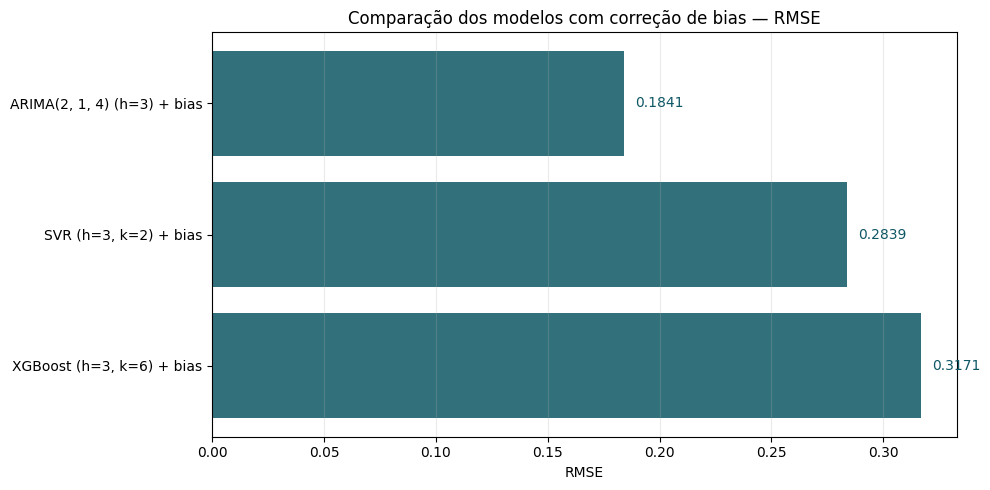

In [27]:
# =============================================================
# Gráfico comparativo — RMSE dos modelos com bias
# =============================================================

COLOR = "#0e5764"

comparativo_plot = (
    comparativo_bias
    .sort_values("RMSE")
    .reset_index(drop=True)
)

plt.figure(figsize=(10, 5))

bars = plt.barh(
    comparativo_plot["Modelo"],
    comparativo_plot["RMSE"],
    color=COLOR,
    alpha=0.85
)

plt.title("Comparação dos modelos com correção de bias — RMSE")
plt.xlabel("RMSE")
plt.ylabel("")
plt.grid(axis="x", alpha=0.25)

plt.gca().invert_yaxis()

for bar in bars:
    largura = bar.get_width()
    plt.text(
        largura + 0.005,
        bar.get_y() + bar.get_height() / 2,
        f"{largura:.4f}",
        va="center",
        fontsize=10,
        color=COLOR
    )

plt.tight_layout()
plt.show()

## Gráficos de Regressão (Previsto vs. Observado)

**Como interpretar o gráfico?**

- **Pontos na diagonal de 45°** → previsões perfeitas
- **Pontos acima da diagonal** → modelo superestima
- **Pontos abaixo da diagonal** → modelo subestima
- **R²** exibido no gráfico → coeficiente de determinação da regressão previsto~observado; quanto mais próximo de 1, melhor o alinhamento

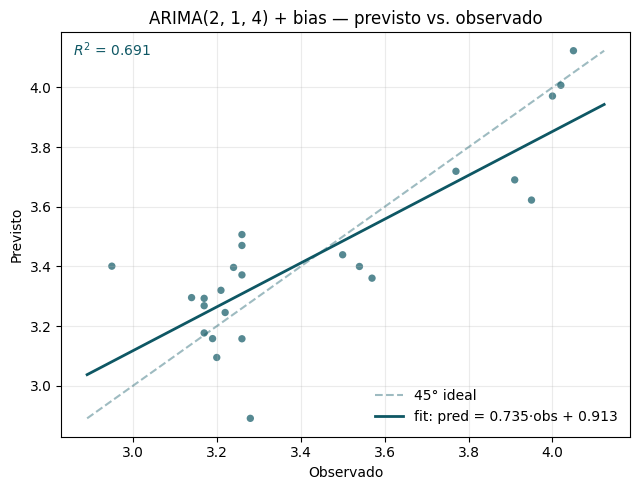

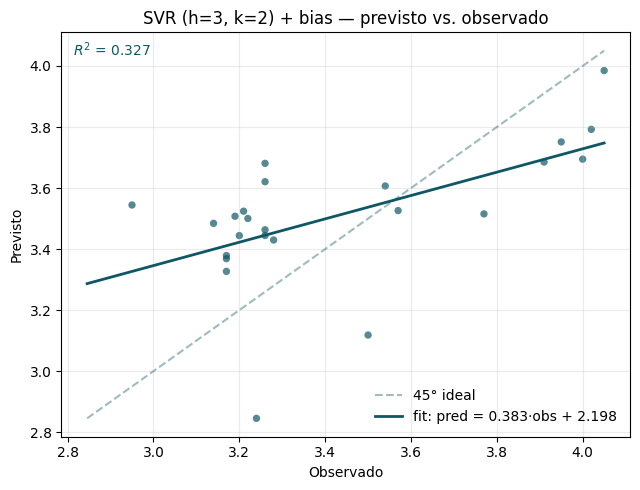

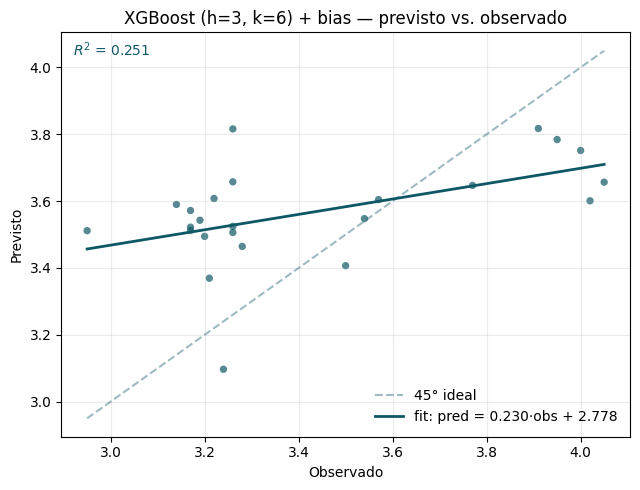

In [31]:
# =============================================================
# Gráficos observado vs. previsto — modelos com correção de bias
# =============================================================

COLOR = "#0e5764"

# Recria variáveis de apoio a partir dos objetos gerados pelos modelos.
# Isso evita erro de NameError caso y_true_h3_svr, y_true_h3_xgb,
# melhor_k_svr ou melhor_k_xgb não tenham sido criados em células anteriores.
melhor_k_svr = int(selecao_svr.sort_values("rmse_treino").iloc[0]["qtd_valores_historicos"])
melhor_k_xgb = int(selecao_xgb.sort_values("rmse_treino").iloc[0]["qtd_valores_historicos"])

y_true_h3_svr = df_reg.loc[yhat_svr_h3.index, TARGET_COL]
y_true_h3_xgb = df_reg.loc[yhat_xgb_h3.index, TARGET_COL]


def plot_regressao(y_true, y_pred, titulo):
    """
    Plota valores observados contra valores previstos.

    A linha diagonal representa o cenário ideal: observado = previsto.
    Pontos acima da diagonal indicam superestimação; pontos abaixo indicam subestimação.
    """
    df_plot = pd.concat(
        [pd.Series(y_true).rename("obs"), pd.Series(y_pred).rename("pred")],
        axis=1
    ).dropna()

    if df_plot.empty:
        raise ValueError("Não há observações suficientes para gerar o gráfico.")

    x = df_plot["obs"].values.reshape(-1, 1)
    y = df_plot["pred"].values

    lr = LinearRegression().fit(x, y)
    r2 = lr.score(x, y)
    slope = float(lr.coef_[0])
    intercept = float(lr.intercept_)

    xy_min = float(min(df_plot["obs"].min(), df_plot["pred"].min()))
    xy_max = float(max(df_plot["obs"].max(), df_plot["pred"].max()))
    xx = np.linspace(xy_min, xy_max, 100)

    plt.figure(figsize=(6.5, 5))

    plt.scatter(
        df_plot["obs"],
        df_plot["pred"],
        s=28,
        alpha=0.7,
        edgecolors="none",
        color=COLOR
    )

    plt.plot(
        [xy_min, xy_max],
        [xy_min, xy_max],
        "--",
        lw=1.5,
        alpha=0.4,
        color=COLOR,
        label="45° ideal"
    )

    plt.plot(
        xx,
        slope * xx + intercept,
        lw=2.0,
        color=COLOR,
        label=f"fit: pred = {slope:.3f}·obs + {intercept:.3f}"
    )

    plt.title(titulo)
    plt.xlabel("Observado")
    plt.ylabel("Previsto")
    plt.grid(True, alpha=0.25)
    plt.legend(frameon=False)

    plt.text(
        0.02,
        0.98,
        f"$R^2$ = {r2:.3f}",
        transform=plt.gca().transAxes,
        ha="left",
        va="top",
        fontsize=10,
        color=COLOR
    )

    plt.tight_layout()
    plt.show()


plot_regressao(
    y_true_h3,
    yhat_h3_bc,
    f"ARIMA{ordem_h3} + bias — previsto vs. observado"
)

plot_regressao(
    y_true_h3_svr,
    yhat_svr_h3_bc,
    f"SVR (h=3, k={melhor_k_svr}) + bias — previsto vs. observado"
)

plot_regressao(
    y_true_h3_xgb,
    yhat_xgb_h3_bc,
    f"XGBoost (h=3, k={melhor_k_xgb}) + bias — previsto vs. observado"
)


In [28]:
df_fit.to_csv("base_modelagem_inadimplencia.csv")